<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>

# **Generación de datos y tratamiento del desbalanceo**

---

## 📁 **Objetivo del notebook**

Este notebook es el punto de partida de todos los notebooks posteriores del curso. Su objetivo es:

1. Generar un dataset sintético realista para auditoría bancaria.
2. Guardar el dataset en formato CSV para que pueda ser leído por los demás scripts.
3. Explicar por qué aparece el desbalanceo en auditoría bancaria.
4. Mostrar métodos de diagnóstico del desbalanceo.
5. Comparar estrategias para salvaguardar el problema:
   - mantener el dataset original,
   - usar pesos de clase,
   - sobremuestreo,
   - submuestreo,
   - SMOTE,
   - ajuste de umbral de decisión,
   - uso de métricas adecuadas.

> **Variable respuesta principal:** `riesgo_auditoria`  
> `0 = Operación normal`  
> `1 = Operación sospechosa / requiere revisión`

## 1. Contexto: ¿por qué hay desbalanceo en auditoría bancaria?

En auditoría bancaria, los eventos de interés suelen ser poco frecuentes:

- fraude transaccional,
- operaciones AML sospechosas,
- documentación KYC incompleta,
- préstamos con riesgo de impago,
- movimientos atípicos,
- operaciones que requieren revisión manual.

Esto genera datasets donde la clase positiva puede representar solo un 1%, 3%, 5% o 10% del total.  
El problema es que un modelo puede obtener una **accuracy muy alta** prediciendo siempre la clase mayoritaria, pero ser completamente inútil para detectar los casos relevantes.

### Ejemplo extremo

Si tenemos 100.000 operaciones y solo 2.000 son sospechosas:

- 98.000 normales → clase 0
- 2.000 sospechosas → clase 1

Un modelo que prediga siempre “normal” tendría un 98% de accuracy, pero detectaría **0 operaciones sospechosas**.

Por eso, en auditoría bancaria no basta con mirar la accuracy. Deben analizarse métricas como:

- recall de la clase positiva,
- precision,
- F1-score,
- matriz de confusión,
- ROC-AUC,
- PR-AUC,
- coste de falsos negativos,
- estabilidad por segmentos,
- calibración de probabilidades.

## 2. Instalación de librerías

Este notebook usa principalmente `pandas`, `numpy`, `scikit-learn` e, idealmente, `imbalanced-learn`.

Si no tienes `imbalanced-learn`, puedes instalarlo con:

```bash
pip install imbalanced-learn
```

> En algunos entornos corporativos o bancarios, la instalación de paquetes puede estar restringida. Por eso el notebook incluye alternativas con `class_weight` y submuestreo/sobremuestreo manual.

In [1]:
import sys
print(sys.executable)

c:\Users\sergi\AppData\Local\Programs\Python\Python313\python.exe


In [2]:
# ============================================================
# 0. LIBRERÍAS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

# Intentamos cargar imbalanced-learn. Si no está instalado, el notebook sigue funcionando.
try:
    from imblearn.over_sampling import RandomOverSampler, SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except Exception as e:
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn no está disponible. Se ejecutarán las partes sin SMOTE.")
    print("Error:", e)

import warnings
warnings.filterwarnings("ignore")

os.environ["LOKY_MAX_CPU_COUNT"] = "8"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 3. Generación de datos sintéticos de auditoría bancaria

Generaremos un dataset tabular con variables típicas de auditoría bancaria.

### Variables numéricas

- `importe_operacion`: importe monetario de la operación.
- `saldo_medio_cliente`: saldo medio del cliente.
- `num_operaciones_30d`: número de operaciones en los últimos 30 días.
- `importe_total_30d`: importe acumulado de operaciones en 30 días.
- `antiguedad_cliente_meses`: antigüedad del cliente.
- `score_crediticio`: score interno aproximado.
- `ratio_ingresos_deuda`: relación ingresos/deuda.
- `num_alertas_previas`: número de alertas anteriores.
- `dias_desde_ultima_revision`: días desde la última revisión de auditoría.
- `porcentaje_operaciones_internacionales`: proporción de operaciones internacionales.

### Variables categóricas

- `canal_operacion`: web, oficina, app, cajero, API.
- `tipo_cliente`: particular, pyme, empresa, banca_privada.
- `pais_riesgo`: bajo, medio, alto.
- `producto`: cuenta, tarjeta, prestamo, transferencia, inversion.
- `segmento_riesgo_cliente`: bajo, medio, alto.

### Variable respuesta

- `riesgo_auditoria`: operación normal o sospechosa.

La clase positiva será minoritaria para simular la realidad bancaria.

In [3]:
# ============================================================
# 1. FUNCIÓN PARA GENERAR DATASET SINTÉTICO
# ============================================================

def generar_datos_auditoria_bancaria(n=15000, tasa_positiva_objetivo=0.06, random_state=42):
    """
    Genera un dataset sintético para auditoría bancaria.
    La variable objetivo riesgo_auditoria está desbalanceada.

    Parámetros
    ----------
    n : int
        Número de observaciones.
    tasa_positiva_objetivo : float
        Proporción aproximada de casos sospechosos.
    random_state : int
        Semilla de reproducibilidad.

    Retorna
    -------
    pandas.DataFrame
        Dataset sintético con variables explicativas y variable respuesta.
    """
    rng = np.random.default_rng(random_state)

    # Variables categóricas
    canal_operacion = rng.choice(
        ["app", "web", "oficina", "cajero", "api"],
        size=n,
        p=[0.42, 0.28, 0.12, 0.13, 0.05]
    )

    tipo_cliente = rng.choice(
        ["particular", "pyme", "empresa", "banca_privada"],
        size=n,
        p=[0.68, 0.18, 0.10, 0.04]
    )

    pais_riesgo = rng.choice(
        ["bajo", "medio", "alto"],
        size=n,
        p=[0.78, 0.17, 0.05]
    )

    producto = rng.choice(
        ["cuenta", "tarjeta", "prestamo", "transferencia", "inversion"],
        size=n,
        p=[0.25, 0.32, 0.12, 0.24, 0.07]
    )

    segmento_riesgo_cliente = rng.choice(
        ["bajo", "medio", "alto"],
        size=n,
        p=[0.65, 0.27, 0.08]
    )

    # Variables numéricas
    antiguedad_cliente_meses = np.clip(rng.gamma(shape=3.5, scale=18, size=n), 1, 360).round(0)
    score_crediticio = np.clip(rng.normal(loc=680, scale=85, size=n), 300, 900).round(0)
    saldo_medio_cliente = np.clip(rng.lognormal(mean=8.7, sigma=1.0, size=n), 100, 500000).round(2)
    importe_operacion = np.clip(rng.lognormal(mean=6.6, sigma=1.15, size=n), 5, 250000).round(2)
    num_operaciones_30d = np.clip(rng.poisson(lam=18, size=n), 0, 180)
    importe_total_30d = (importe_operacion * rng.uniform(1.5, 14, size=n) + rng.normal(0, 2500, size=n))
    importe_total_30d = np.clip(importe_total_30d, 0, 1000000).round(2)
    ratio_ingresos_deuda = np.clip(rng.beta(a=2.2, b=5.5, size=n), 0, 1).round(3)
    num_alertas_previas = np.clip(rng.poisson(lam=0.45, size=n), 0, 10)
    dias_desde_ultima_revision = np.clip(rng.exponential(scale=110, size=n), 1, 900).round(0)
    porcentaje_operaciones_internacionales = np.clip(rng.beta(a=1.2, b=8.0, size=n), 0, 1).round(3)

    # Reglas latentes de riesgo: combinación de variables numéricas y categóricas
    logit = (
        -5.0
        + 0.000010 * importe_operacion
        + 0.000003 * importe_total_30d
        + 0.20 * num_alertas_previas
        + 1.20 * porcentaje_operaciones_internacionales
        + 0.003 * np.maximum(650 - score_crediticio, 0)
        + 0.50 * (pais_riesgo == "alto")
        + 0.22 * (pais_riesgo == "medio")
        + 0.45 * (segmento_riesgo_cliente == "alto")
        + 0.20 * (segmento_riesgo_cliente == "medio")
        + 0.25 * (canal_operacion == "api")
        + 0.18 * (producto == "transferencia")
        + 0.15 * (producto == "inversion")
        + 0.18 * (tipo_cliente == "empresa")
        - 0.004 * antiguedad_cliente_meses
    )

    prob_base = 1 / (1 + np.exp(-logit))

    # Ajuste para aproximar la tasa positiva objetivo.
    # Se desplaza el umbral sobre probabilidades para seleccionar el top de riesgo.
    umbral = np.quantile(prob_base, 1 - tasa_positiva_objetivo)
    riesgo_auditoria = (prob_base >= umbral).astype(int)

    # Añadimos algo de ruido: algunos casos normales se revisan y algunos sospechosos pasan desapercibidos.
    flip_pos = rng.random(n) < 0.005
    riesgo_auditoria = np.where(flip_pos, 1 - riesgo_auditoria, riesgo_auditoria)

    df = pd.DataFrame({
        "id_operacion": np.arange(1, n + 1),
        "importe_operacion": importe_operacion,
        "saldo_medio_cliente": saldo_medio_cliente,
        "num_operaciones_30d": num_operaciones_30d,
        "importe_total_30d": importe_total_30d,
        "antiguedad_cliente_meses": antiguedad_cliente_meses,
        "score_crediticio": score_crediticio,
        "ratio_ingresos_deuda": ratio_ingresos_deuda,
        "num_alertas_previas": num_alertas_previas,
        "dias_desde_ultima_revision": dias_desde_ultima_revision,
        "porcentaje_operaciones_internacionales": porcentaje_operaciones_internacionales,
        "canal_operacion": canal_operacion,
        "tipo_cliente": tipo_cliente,
        "pais_riesgo": pais_riesgo,
        "producto": producto,
        "segmento_riesgo_cliente": segmento_riesgo_cliente,
        "riesgo_auditoria": riesgo_auditoria
    })

    return df


df = generar_datos_auditoria_bancaria(n=15000, tasa_positiva_objetivo=0.06, random_state=RANDOM_STATE)
df.head()

,id_operacion,importe_operacion,saldo_medio_cliente,num_operaciones_30d,importe_total_30d,antiguedad_cliente_meses,score_crediticio,ratio_ingresos_deuda,num_alertas_previas,dias_desde_ultima_revision,porcentaje_operaciones_internacionales,canal_operacion,tipo_cliente,pais_riesgo,producto,segmento_riesgo_cliente,riesgo_auditoria
0,1,233.39,11739.05,17,3085.27,25.0,763.0,0.309,1,31.0,0.003,oficina,particular,bajo,prestamo,medio,0
1,2,829.72,411.47,15,10457.08,80.0,665.0,0.248,1,37.0,0.007,web,particular,bajo,transferencia,medio,0
2,3,176.14,2928.34,23,5525.19,21.0,610.0,0.257,0,269.0,0.439,cajero,particular,alto,tarjeta,medio,1
3,4,2141.27,3579.99,16,2347.29,71.0,776.0,0.211,0,326.0,0.120,web,pyme,bajo,cuenta,alto,0
4,5,1039.73,1938.84,16,9070.86,27.0,626.0,0.278,0,150.0,0.179,app,particular,bajo,cuenta,bajo,0


In [4]:
# Dimensiones del dataset
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

# Distribución de la variable respuesta
conteo = df["riesgo_auditoria"].value_counts().sort_index()
porcentaje = df["riesgo_auditoria"].value_counts(normalize=True).sort_index() * 100

pd.DataFrame({
    "conteo": conteo,
    "porcentaje": porcentaje.round(2)
})

Filas: 15000
Columnas: 17


,conteo,porcentaje
riesgo_auditoria,,
0,14052,93.68
1,948,6.32


## 4. Guardar el CSV para los demás notebooks

Este CSV será el fichero común que podrán leer los notebooks posteriores:

```python
pd.read_csv("data/auditoria_bancaria_desbalanceada.csv")
```

Se recomienda mantener siempre una copia del dataset original desbalanceado.  
Los métodos de balanceo deben aplicarse **solo dentro del entrenamiento**, nunca antes de separar train/test.

In [5]:
# ============================================================
# 2. GUARDAR CSV BASE
# ============================================================

os.makedirs("../../data", exist_ok=True)
ruta_csv = "../../data/auditoria_bancaria_desbalanceada.csv"
df.to_csv(ruta_csv, index=False, encoding="utf-8")

print(f"CSV generado correctamente en: {ruta_csv}")
print("Este fichero será usado por los demás notebooks del curso.")

CSV generado correctamente en: ../../data/auditoria_bancaria_desbalanceada.csv
Este fichero será usado por los demás notebooks del curso.


## 5. Diagnóstico del desbalanceo

Antes de aplicar modelos, un auditor debe cuantificar el desbalanceo.

### Preguntas clave

1. ¿Cuál es la proporción de clase positiva?
2. ¿La clase minoritaria representa menos del 10%?
3. ¿La métrica `accuracy` puede ser engañosa?
4. ¿Cuál es el coste de no detectar un caso sospechoso?
5. ¿Se quiere maximizar recall, precision o equilibrio F1?
6. ¿El modelo se usará para automatizar decisiones o para priorizar revisión manual?

En banca, normalmente no se busca solo “acertar”, sino **priorizar correctamente los casos que deben revisarse**.

In [6]:
# ============================================================
# 3. FUNCIÓN DE DIAGNÓSTICO DEL DESBALANCEO
# ============================================================

def diagnostico_desbalanceo(y):
    conteo = y.value_counts().sort_index()
    porcentaje = y.value_counts(normalize=True).sort_index() * 100
    ratio_mayoritaria_minoritaria = conteo.max() / conteo.min()

    resumen = pd.DataFrame({
        "clase": conteo.index,
        "conteo": conteo.values,
        "porcentaje": porcentaje.values.round(2)
    })

    print("RESUMEN DEL DESBALANCEO")
    print("=" * 45)
    display(resumen)
    print(f"Ratio clase mayoritaria / minoritaria: {ratio_mayoritaria_minoritaria:.2f}:1")

    if porcentaje.min() < 5:
        print("Diagnóstico: desbalanceo severo.")
    elif porcentaje.min() < 15:
        print("Diagnóstico: desbalanceo moderado.")
    else:
        print("Diagnóstico: desbalanceo leve o aceptable.")

    return resumen

resumen_desbalanceo = diagnostico_desbalanceo(df["riesgo_auditoria"])

RESUMEN DEL DESBALANCEO


,clase,conteo,porcentaje
0,0,14052,93.68
1,1,948,6.32


Ratio clase mayoritaria / minoritaria: 14.82:1
Diagnóstico: desbalanceo moderado.


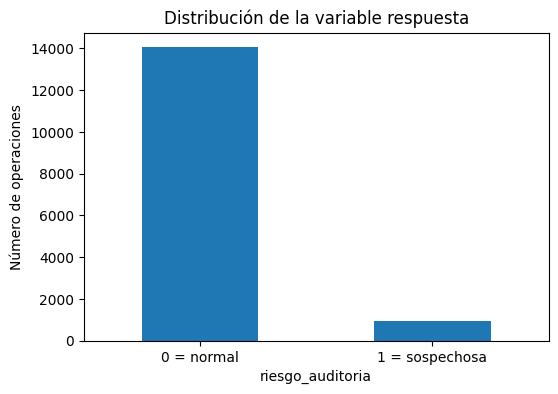

In [7]:
# Visualización simple de la variable respuesta
ax = df["riesgo_auditoria"].value_counts().sort_index().plot(kind="bar", figsize=(6, 4))
ax.set_title("Distribución de la variable respuesta")
ax.set_xlabel("riesgo_auditoria")
ax.set_ylabel("Número de operaciones")
ax.set_xticklabels(["0 = normal", "1 = sospechosa"], rotation=0)
plt.show()

## 6. Separación train/test: punto crítico para auditoría

Una mala práctica habitual es aplicar SMOTE, oversampling o undersampling **antes** de dividir en entrenamiento y test.

Esto produce fuga de información porque el test deja de representar datos reales.

### Regla correcta

1. Separar `X_train`, `X_test`, `y_train`, `y_test`.
2. Ajustar el preprocesamiento solo con train.
3. Aplicar balanceo solo dentro de train.
4. Evaluar siempre sobre test original desbalanceado.

> En auditoría, el test debe parecerse al mundo real: muchos casos normales y pocos casos sospechosos.

In [8]:
# ============================================================
# 4. TRAIN / TEST
# ============================================================

X = df.drop(columns=["riesgo_auditoria", "id_operacion"])
y = df["riesgo_auditoria"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Distribución en train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nDistribución en test:")
print(y_test.value_counts(normalize=True).round(4))

Distribución en train:
riesgo_auditoria
0    0.9368
1    0.0632
Name: proportion, dtype: float64

Distribución en test:
riesgo_auditoria
0    0.9368
1    0.0632
Name: proportion, dtype: float64


## 7. Preprocesamiento común

Las variables numéricas se escalan con `StandardScaler` y las categóricas se convierten con `OneHotEncoder`.

Este preprocesamiento se integrará dentro de un `Pipeline` para evitar fuga de información.

In [9]:
# ============================================================
# 5. PREPROCESAMIENTO
# ============================================================

variables_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), variables_categoricas)
    ]
)

Variables numéricas: ['importe_operacion', 'saldo_medio_cliente', 'num_operaciones_30d', 'importe_total_30d', 'antiguedad_cliente_meses', 'score_crediticio', 'ratio_ingresos_deuda', 'num_alertas_previas', 'dias_desde_ultima_revision', 'porcentaje_operaciones_internacionales']
Variables categóricas: ['canal_operacion', 'tipo_cliente', 'pais_riesgo', 'producto', 'segmento_riesgo_cliente']


## 8. Función común de evaluación

En problemas desbalanceados, la evaluación debe mirar más allá de la accuracy.

### Interpretación para auditoría

- **Recall clase 1:** de todos los casos sospechosos reales, cuántos detecta el modelo.
- **Precision clase 1:** de todos los casos marcados como sospechosos, cuántos realmente lo son.
- **F1-score:** equilibrio entre precision y recall.
- **ROC-AUC:** capacidad global de ordenación entre clases.
- **PR-AUC:** especialmente útil cuando la clase positiva es minoritaria.
- **Matriz de confusión:** permite ver falsos negativos y falsos positivos.

En auditoría bancaria suele ser crítico controlar los **falsos negativos**: casos sospechosos que el modelo no detecta.

In [10]:
# ============================================================
# 6. FUNCIÓN DE EVALUACIÓN
# ============================================================

def evaluar_modelo(nombre, modelo, X_test, y_test, umbral=0.5):
    """
    Evalúa un modelo de clasificación binaria usando un umbral concreto.
    """
    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= umbral).astype(int)

    metricas = {
        "modelo": nombre,
        "umbral": umbral,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_clase_1": precision_score(y_test, y_pred, zero_division=0),
        "recall_clase_1": recall_score(y_test, y_pred, zero_division=0),
        "f1_clase_1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob)
    }

    print(f"RESULTADOS: {nombre}")
    print("=" * 60)
    print(pd.Series(metricas))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Sospechosa"])
    disp.plot(values_format="d")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

    return metricas

## 9. Modelo base sin tratar el desbalanceo

Primero entrenamos un modelo sin ninguna estrategia especial.

Este modelo sirve como baseline, pero no necesariamente será aceptable en auditoría.

RESULTADOS: Logistic Regression - sin balanceo
modelo               Logistic Regression - sin balanceo
umbral                                              0.5
accuracy                                       0.979467
precision_clase_1                               0.93956
recall_clase_1                                 0.721519
f1_clase_1                                     0.816229
roc_auc                                        0.953862
pr_auc                                         0.879371
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3513
           1       0.94      0.72      0.82       237

    accuracy                           0.98      3750
   macro avg       0.96      0.86      0.90      3750
weighted avg       0.98      0.98      0.98      3750



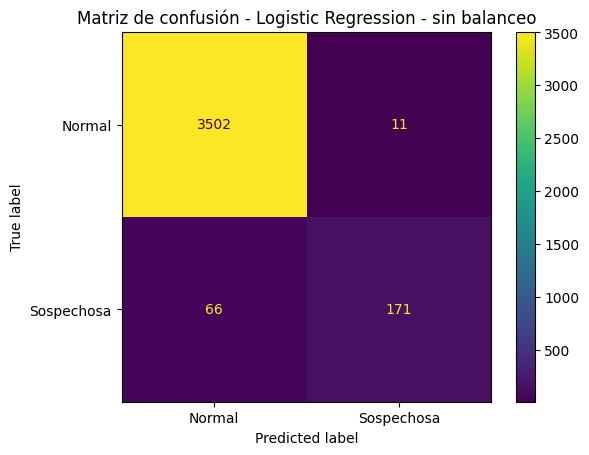

In [11]:
# ============================================================
# 7. MODELO BASE SIN TRATAR DESBALANCEO
# ============================================================

modelo_base = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

modelo_base.fit(X_train, y_train)
metricas_base = evaluar_modelo("Logistic Regression - sin balanceo", modelo_base, X_test, y_test)

## 10. Método 1: pesos de clase (`class_weight`)

Una solución muy usada en auditoría es asignar más peso a la clase minoritaria.

En `scikit-learn`, `class_weight="balanced"` calcula pesos inversamente proporcionales a la frecuencia de las clases.

### Ventajas

- No modifica los datos originales.
- Reduce el sesgo hacia la clase mayoritaria.
- Es fácil de auditar y justificar.
- Funciona bien con modelos lineales, árboles y SVM.

### Riesgos

- Puede aumentar los falsos positivos.
- No siempre mejora la calibración de probabilidades.
- Debe validarse por segmento de cliente/producto.

In [12]:
# Cálculo explícito de pesos de clase
clases = np.array([0, 1])
pesos = compute_class_weight(class_weight="balanced", classes=clases, y=y_train)

pd.DataFrame({
    "clase": clases,
    "peso_calculado": pesos.round(3)
})

,clase,peso_calculado
0,0,0.534
1,1,7.911


RESULTADOS: Logistic Regression - class_weight balanced
modelo               Logistic Regression - class_weight balanced
umbral                                                       0.5
accuracy                                                0.918933
precision_clase_1                                         0.4334
recall_clase_1                                          0.919831
f1_clase_1                                              0.589189
roc_auc                                                 0.953241
pr_auc                                                  0.871519
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      3513
           1       0.43      0.92      0.59       237

    accuracy                           0.92      3750
   macro avg       0.71      0.92      0.77      3750
weighted avg       0.96      0.92      0.93      3750



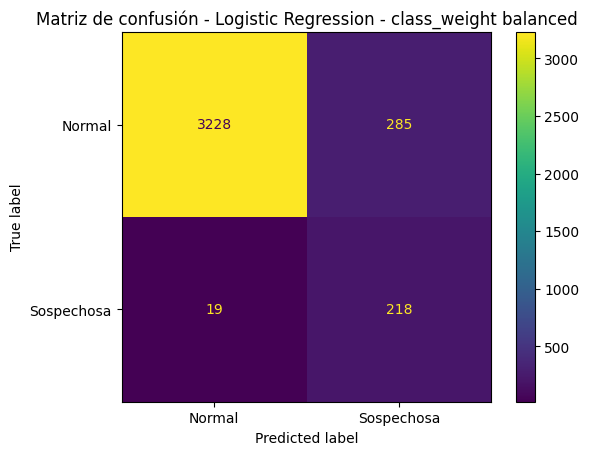

In [13]:
modelo_class_weight = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

modelo_class_weight.fit(X_train, y_train)
metricas_class_weight = evaluar_modelo("Logistic Regression - class_weight balanced", modelo_class_weight, X_test, y_test)

## 11. Método 2: sobremuestreo aleatorio

El sobremuestreo aleatorio replica observaciones de la clase minoritaria en el conjunto de entrenamiento.

### Ventajas

- Sencillo.
- Puede mejorar el recall.
- Fácil de explicar.

### Riesgos

- Puede sobreajustar, porque duplica casos existentes.
- No genera nueva información.
- Debe aplicarse solo al train.

RESULTADOS: Logistic Regression - Random Oversampling
modelo               Logistic Regression - Random Oversampling
umbral                                                     0.5
accuracy                                                0.9184
precision_clase_1                                     0.431412
recall_clase_1                                        0.915612
f1_clase_1                                            0.586486
roc_auc                                               0.953024
pr_auc                                                0.871407
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      3513
           1       0.43      0.92      0.59       237

    accuracy                           0.92      3750
   macro avg       0.71      0.92      0.77      3750
weighted avg       0.96      0.92      0.93      3750



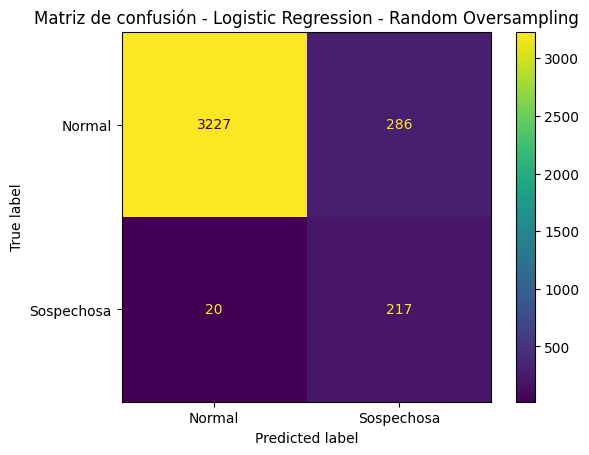

In [14]:
# ============================================================
# 8. OVERSAMPLING ALEATORIO
# ============================================================

if IMBLEARN_AVAILABLE:
    modelo_oversampling = ImbPipeline(steps=[
        ("preprocesador", preprocesador),
        ("oversampling", RandomOverSampler(random_state=RANDOM_STATE)),
        ("modelo", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])

    modelo_oversampling.fit(X_train, y_train)
    metricas_oversampling = evaluar_modelo("Logistic Regression - Random Oversampling", modelo_oversampling, X_test, y_test)
else:
    metricas_oversampling = None
    print("No se ejecuta RandomOverSampler porque imbalanced-learn no está instalado.")

## 12. Método 3: submuestreo aleatorio

El submuestreo reduce la clase mayoritaria para equilibrar el dataset.

### Ventajas

- Reduce tiempo de entrenamiento.
- Puede ser útil con datasets muy grandes.
- Evita duplicar observaciones.

### Riesgos

- Pierde información de la clase mayoritaria.
- Puede empeorar la estabilidad del modelo.
- En banca, debe usarse con cuidado porque se descartan operaciones reales.

RESULTADOS: Logistic Regression - Random Undersampling
modelo               Logistic Regression - Random Undersampling
umbral                                                      0.5
accuracy                                               0.914933
precision_clase_1                                      0.420849
recall_clase_1                                         0.919831
f1_clase_1                                             0.577483
roc_auc                                                0.952167
pr_auc                                                 0.857747
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      3513
           1       0.42      0.92      0.58       237

    accuracy                           0.91      3750
   macro avg       0.71      0.92      0.77      3750
weighted avg       0.96      0.91      0.93      3750



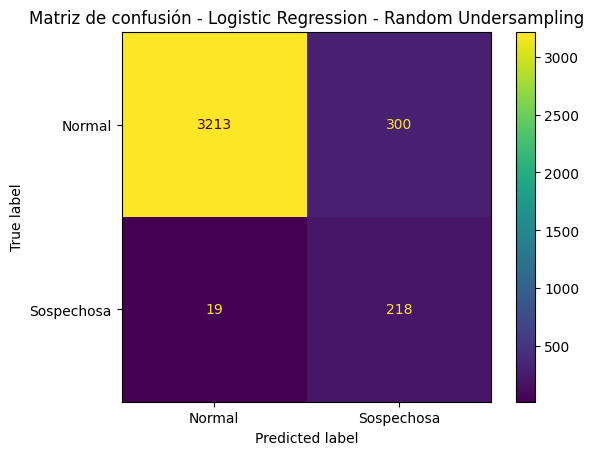

In [15]:
# ============================================================
# 9. UNDERSAMPLING ALEATORIO
# ============================================================

if IMBLEARN_AVAILABLE:
    modelo_undersampling = ImbPipeline(steps=[
        ("preprocesador", preprocesador),
        ("undersampling", RandomUnderSampler(random_state=RANDOM_STATE)),
        ("modelo", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])

    modelo_undersampling.fit(X_train, y_train)
    metricas_undersampling = evaluar_modelo("Logistic Regression - Random Undersampling", modelo_undersampling, X_test, y_test)
else:
    metricas_undersampling = None
    print("No se ejecuta RandomUnderSampler porque imbalanced-learn no está instalado.")

## 13. Método 4: SMOTE

SMOTE genera ejemplos sintéticos de la clase minoritaria interpolando entre observaciones cercanas.

### Ventajas

- No se limita a duplicar observaciones.
- Puede mejorar la frontera de decisión.
- Es útil cuando hay pocos casos positivos.

### Riesgos para auditoría bancaria

- Puede crear ejemplos sintéticos difíciles de justificar.
- Puede generar combinaciones poco realistas si hay muchas variables categóricas codificadas.
- Debe documentarse claramente.
- No debe aplicarse sobre el test.
- Puede ser menos adecuado si los positivos son muy heterogéneos.

> En datasets mixtos con muchas categóricas, puede valorarse `SMOTENC`, aunque este notebook usa `SMOTE` después de codificación para mantener simplicidad docente.

RESULTADOS: Logistic Regression - SMOTE
modelo               Logistic Regression - SMOTE
umbral                                       0.5
accuracy                                  0.9272
precision_clase_1                       0.461702
recall_clase_1                          0.915612
f1_clase_1                              0.613861
roc_auc                                  0.95236
pr_auc                                  0.860945
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      3513
           1       0.46      0.92      0.61       237

    accuracy                           0.93      3750
   macro avg       0.73      0.92      0.79      3750
weighted avg       0.96      0.93      0.94      3750



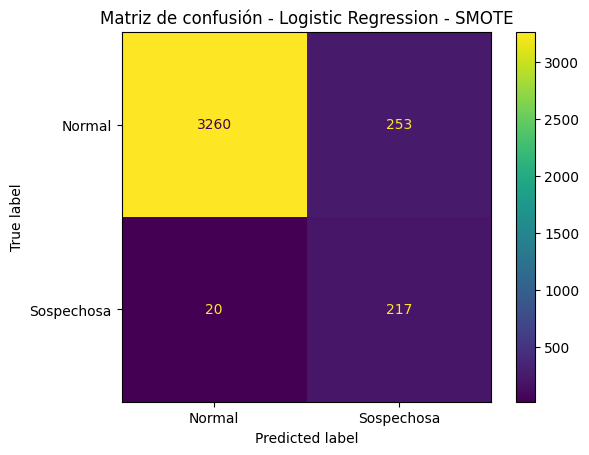

In [16]:
# ============================================================
# 10. SMOTE
# ============================================================

if IMBLEARN_AVAILABLE:
    modelo_smote = ImbPipeline(steps=[
        ("preprocesador", preprocesador),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("modelo", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]) # usa todos los disponibles

    modelo_smote.fit(X_train, y_train)
    metricas_smote = evaluar_modelo("Logistic Regression - SMOTE", modelo_smote, X_test, y_test)
else:
    metricas_smote = None
    print("No se ejecuta SMOTE porque imbalanced-learn no está instalado.")

## 14. Método 5: ajuste del umbral de decisión

Por defecto, muchos modelos clasifican como clase 1 si la probabilidad es mayor o igual a 0.5.

En auditoría bancaria, este umbral puede no ser adecuado.  
Si queremos detectar más casos sospechosos, podemos bajar el umbral, por ejemplo a 0.30 o 0.20.

### Consecuencia

- Baja el umbral → sube el recall, pero suelen subir los falsos positivos.
- Sube el umbral → sube la precision, pero puede bajar el recall.

El umbral debe definirse según el coste operativo:

- ¿Cuántas operaciones puede revisar el equipo auditor?
- ¿Cuál es el coste de un falso negativo?
- ¿Cuál es el coste de un falso positivo?

In [17]:
# ============================================================
# 11. ANÁLISIS DE UMBRALES
# ============================================================

umbrales = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
resultados_umbrales = []

for u in umbrales:
    y_prob = modelo_class_weight.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= u).astype(int)
    resultados_umbrales.append({
        "umbral": u,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_clase_1": precision_score(y_test, y_pred, zero_division=0),
        "recall_clase_1": recall_score(y_test, y_pred, zero_division=0),
        "f1_clase_1": f1_score(y_test, y_pred, zero_division=0),
        "operaciones_marcadas_sospechosas": int(y_pred.sum())
    })

pd.DataFrame(resultados_umbrales)

,umbral,accuracy,precision_clase_1,recall_clase_1,f1_clase_1,operaciones_marcadas_sospechosas
0,0.1,0.697867,0.166667,0.945148,0.283365,1344
1,0.2,0.799200,0.231809,0.940928,0.371977,962
2,0.3,0.850933,0.288714,0.928270,0.440440,762
3,0.4,0.890933,0.359477,0.928270,0.518257,612
4,0.5,0.918933,0.433400,0.919831,0.589189,503
5,0.6,0.944533,0.536160,0.907173,0.673981,401


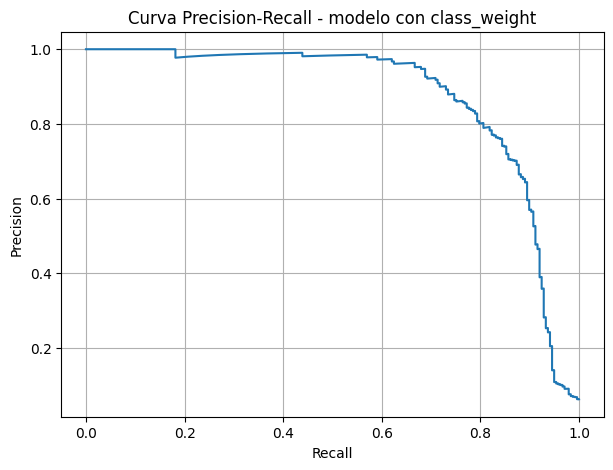

In [18]:
# Curva Precision-Recall para decidir umbral
prob_test = modelo_class_weight.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, prob_test)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - modelo con class_weight")
plt.grid(True)
plt.show()

## 15. Comparación final de estrategias

No existe una única solución universal. Para auditoría bancaria, la decisión depende de:

- objetivo del modelo,
- riesgo regulatorio,
- capacidad de revisión manual,
- coste de falsos negativos,
- coste de falsos positivos,
- explicabilidad requerida,
- estabilidad temporal,
- robustez por segmentos.

In [19]:
# ============================================================
# 12. TABLA COMPARATIVA DE MÉTRICAS
# ============================================================

lista_metricas = [metricas_base, metricas_class_weight]

for m in [metricas_oversampling, metricas_undersampling, metricas_smote]:
    if m is not None:
        lista_metricas.append(m)

comparativa = pd.DataFrame(lista_metricas)
comparativa.sort_values(by="recall_clase_1", ascending=False)

,modelo,umbral,accuracy,precision_clase_1,recall_clase_1,f1_clase_1,roc_auc,pr_auc
1,Logistic Regression - class_weight balanced,0.5,0.918933,0.433400,0.919831,0.589189,0.953241,0.871519
3,Logistic Regression - Random Undersampling,0.5,0.914933,0.420849,0.919831,0.577483,0.952167,0.857747
2,Logistic Regression - Random Oversampling,0.5,0.918400,0.431412,0.915612,0.586486,0.953024,0.871407
4,Logistic Regression - SMOTE,0.5,0.927200,0.461702,0.915612,0.613861,0.952360,0.860945
0,Logistic Regression - sin balanceo,0.5,0.979467,0.939560,0.721519,0.816229,0.953862,0.879371


## 16. Recomendaciones para auditores bancarios

### Buenas prácticas

1. Mantener un test realista y desbalanceado.
2. No aplicar SMOTE antes de train/test split.
3. Comparar varias estrategias de balanceo.
4. Reportar siempre métricas por clase.
5. Revisar recall y precision de la clase minoritaria.
6. Usar PR-AUC cuando la clase positiva es rara.
7. Ajustar el umbral según capacidad operativa.
8. Documentar el método usado y su impacto.
9. Validar estabilidad por segmentos: canal, producto, país, tipo de cliente.
10. Monitorizar drift y cambios de proporción de clase positiva.

### Señales de alerta

- Accuracy muy alta pero recall bajo.
- Modelo que casi nunca predice clase positiva.
- Oversampling aplicado antes de separar train/test.
- Umbral 0.5 usado sin justificación.
- SMOTE usado sin explicar implicaciones.
- Métricas reportadas solo a nivel global.
- Ausencia de matriz de confusión.

## 17. Checklist de auditoría del desbalanceo

| Pregunta | Respuesta esperada |
|---|---|
| ¿Se ha medido la proporción de clases? | Sí |
| ¿Se ha mantenido el test original? | Sí |
| ¿Se ha evitado fuga de información? | Sí |
| ¿Se han probado métodos alternativos? | Sí |
| ¿Se reporta recall de la clase positiva? | Sí |
| ¿Se reporta precision de la clase positiva? | Sí |
| ¿Se ha analizado PR-AUC? | Sí |
| ¿Se ha justificado el umbral? | Sí |
| ¿Se ha valorado coste de FN y FP? | Sí |
| ¿Se ha documentado la estrategia final? | Sí |

## 18. Carga del CSV desde otros notebooks

En los siguientes notebooks, se podrá cargar el dataset así:

In [ ]:
# Ejemplo de carga para notebooks posteriores
ruta_csv = "../../data/auditoria_bancaria_desbalanceada.csv"
datos = pd.read_csv(ruta_csv)

datos.head()

## 19. Mini ejercicio guiado

Modifica los siguientes parámetros y observa cómo cambian las métricas:

1. Cambia `tasa_positiva_objetivo` de 0.06 a 0.03.
2. Repite el entrenamiento.
3. Compara el modelo base con `class_weight`.
4. Baja el umbral de 0.50 a 0.30.
5. Analiza si mejora el recall y cuántas operaciones adicionales se revisarían.

### Pregunta de auditoría

¿Aceptarías un modelo con más falsos positivos si reduce mucho los falsos negativos?

La respuesta debe justificarse con:

- matriz de confusión,
- coste de revisión manual,
- severidad del riesgo,
- capacidad operativa del equipo auditor.

# ✅ Conclusión

Este notebook genera el dataset base y explica uno de los problemas más importantes en auditoría bancaria: el desbalanceo.

La idea principal es que un modelo no debe evaluarse solo por accuracy.  
En problemas donde la clase positiva representa eventos de riesgo, fraude o incumplimiento, el análisis debe centrarse en la capacidad de detectar esos casos sin saturar el proceso de revisión.

El CSV generado podrá reutilizarse en los notebooks posteriores de:

- Regresión Logística,
- Random Forest,
- Boosting,
- SVM,
- Evaluación e Interpretación,
- Redes Neuronales,
- End-to-End Software.